# **Seasonal Agriculture Performance Analysis**
## Major Data Analytics Project
* **Domain:** Agriculture
* **Project Theme:** Seasonal Agriculture Performance
* **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

* **Project Goal:** Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships, and differences in the available data.

##Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and economic conditions. As a result, agricultural performance may differ significantly from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.


## Project Objectives

* Explore and understand the dataset structure, features, and data types.
* Clean and prepare the agricultural dataset for analytical processing.
* Analyze seasonal variations in crop yields, farm profitability, and resource usage.
* Apply descriptive statistical methods to measure performance differences across seasons.
* Conduct univariate, bivariate, and multivariate analysis with expressive visualizations.
* Identify significant patterns, trends, and relationships to derive evidence-based conclusions.

---

## Dataset Overview

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production outputs, financial metrics, and resource usage[cite: 1].

* **Dataset File:** `seasonal_agriculture_performance_dataset.csv`
* **Total Rows:** 4,000 farm records
* **Total Columns:** 28 parameters


In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Libraries imported successfully!")

Libraries imported successfully!


In [118]:
import os
import pandas as pd

file_name = "seasonal_agriculture_performance_dataset.csv"

if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    if csv_files:
        print(f"Found file: {csv_files[0]}")
        df = pd.read_csv(csv_files[0])
        print("Dataset loaded successfully!")
        print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    else:
        print("ERROR: Please upload 'seasonal_agriculture_performance_dataset.csv' ")

Dataset loaded successfully!
Shape: 4000 rows, 28 columns


### Dataset Shape

In [119]:
print("Dataset Shape:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset Shape:
Number of rows: 4000
Number of columns: 28


### Top 5 rows

In [120]:
print("\n--- Top 5 Rows (Head) ---")
display(df.head(5))


--- Top 5 Rows (Head) ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


### Bottom 5 rows

In [121]:
print("\n--- Bottom 5 Rows (Tail) ---")
display(df.tail(5))


--- Bottom 5 Rows (Tail) ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


### Random sample of 5 records

In [122]:
print("\n--- Random Sample of 5 Records ---")
display(df.sample(5, random_state=42))


--- Random Sample of 5 Records ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


### Column Names


In [123]:
print("\n--- Column Names ---")
print(df.columns.tolist())


--- Column Names ---
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


### Data Types and Non-Null Counts


In [124]:
print("\n--- Data Types & Non-Null Counts ---")
df.info()


--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_k

### Numerical Summary Statistics

In [125]:
print("\n--- Numerical Summary Statistics ---")
display(df.describe())


--- Numerical Summary Statistics ---


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


###Categorical Summary Statistics


In [126]:
print("\n--- Categorical Summary Statistics ---")
display(df.describe(include="object"))


--- Categorical Summary Statistics ---


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## Data Quality Analysis

### Checking Missing Values

In [127]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage
})
missing_summary_filtered = missing_summary[missing_summary['Missing Count'] > 0]
print("--- Missing Values Summary ---")
display(missing_summary_filtered)

--- Missing Values Summary ---


,Missing Count,Missing Percentage (%)
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


### Visualizing Missing Values


/tmp/ipykernel_1593/3301488016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_summary_filtered.index, y=missing_summary_filtered['Missing Count'], palette='Reds_d')


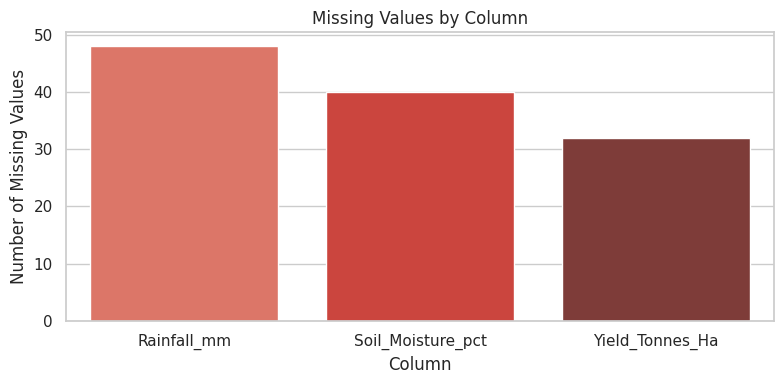

In [128]:
plt.figure(figsize=(8, 4))
if len(missing_summary_filtered) > 0:
    sns.barplot(x=missing_summary_filtered.index, y=missing_summary_filtered['Missing Count'], palette='Reds_d')
    plt.title("Missing Values by Column")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

### Duplicate Records Analysis

In [129]:
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


### Remove Duplicate Rows (if any)

In [130]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after duplicate removal: {df.shape}")

Dataset shape after duplicate removal: (4000, 28)


###  Check Unique Values of Categorical Columns

In [131]:
print("\n--- Unique Values in Categorical Columns ---")
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
    unique_vals = df[col].dropna().unique()
    print(f"\n{col} ({len(unique_vals)} unique values):")
    print(unique_vals[:10])


--- Unique Values in Categorical Columns ---

Farm_ID (4000 unique values):
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010']

State (8 unique values):
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District (10 unique values):
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop (8 unique values):
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season (3 unique values):
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method (4 unique values):
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


### Check Missing Values After Duplicate Removal

In [132]:

print("\n--- Remaining Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])


--- Remaining Missing Values ---
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


## Missing Value Treatment

In this dataset, missing values exist in `Rainfall_mm` (48 records), `Soil_Moisture_pct` (40 records), and `Yield_Tonnes_Ha` (32 records).


In [133]:

missing_cols = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
for col in missing_cols:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

print("--- Missing Values After Treatment ---")
print(df[missing_cols].isnull().sum())
print(f"\nTotal remaining missing values across entire dataset: {df.isnull().sum().sum()}")

--- Missing Values After Treatment ---
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64

Total remaining missing values across entire dataset: 0


## Feature/Variable Review

To systematically address the seasonal agriculture performance problem, we categorize the 28 dataset variables based on their analytical role:

* **Identifier Variables:** `Farm_ID` (Unique identifier for each farm record).

* **Categorical / Spatial Variables:** `State`, `District`, `Crop`, `Season`, `Irrigation_Method` (Define geographical context, crop varieties, agricultural season, and water management practices).

* **Environmental Variables:** `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, `Soil_Moisture_pct` (Capture seasonal atmospheric and soil conditions).

* **Operational Variables:** `Farm_Area_Hectares`, `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Seed_Quality_Score`, `Water_Used_m3` (Quantify input resource allocation).

* **Production & Economic Performance Variables:** `Yield_Tonnes_Ha`, `Production_Tonnes`, `Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR`, `Water_Efficiency_t_per_1000m3`, `Disease_Pest_Risk_pct` (Core outcome metrics evaluating yield productivity, financial viability, and pest risks across seasons).

### Key Relevant Variables for Seasonal Analysis:
1. **`Season`:** Primary grouping variable (`Kharif`, `Rabi`, `Zaid`) required to slice and compare performance across periods.

2. **`Yield_Tonnes_Ha` & `Production_Tonnes`:** Key indicators measuring physical agricultural productivity per season.

3. **`Profit_INR` & `Revenue_INR`:** Key indicators evaluating financial performance and economic viability.

4. **`Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`:** Fundamental climatic drivers causing seasonal yield and profit variations.

In [134]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("--- Numerical Columns ---")
print(numeric_columns)

print("\n--- Categorical Columns ---")
print(categorical_columns)

--- Numerical Columns ---
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

--- Categorical Columns ---
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


##Statistical Analysis

### Detailed Descriptive Statistics

In [135]:
stats = df[numeric_columns].describe().T
stats['range'] = stats['max'] - stats['min']
stats['IQR'] = stats['75%'] - stats['25%']
print("--- Overall Descriptive Statistics ---")
display(stats)


--- Overall Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,4000.00,600.72,288.42,80.00,370.43,581.00,835.95,1395.20,1315.20,465.53
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,4000.00,26.51,6.70,8.00,21.70,26.40,31.30,47.00,39.00,9.60
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


### Key Statistical Measures

In [136]:
statistical_summary = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Std_Dev': df[numeric_columns].std(),
    'Min': df[numeric_columns].min(),
    'Max': df[numeric_columns].max()
})
print("\n--- Statistical Central Tendency & Dispersion Summary ---")
display(statistical_summary)



--- Statistical Central Tendency & Dispersion Summary ---


,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.72,581.00,288.42,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.70,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


###Seasonal Descriptive Summary

In [137]:

seasonal_stats = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C', 'Disease_Pest_Risk_pct']].agg(['mean', 'median', 'std'])
print("\n--- Seasonal Descriptive Summary ---")
display(seasonal_stats)


--- Seasonal Descriptive Summary ---


Yield_Tonnes_Ha              Profit_INR                      \
                  mean median   std       mean    median       std   
Season                                                               
Kharif            5.63   1.95 14.39  178914.65  38808.00 611549.78   
Rabi              5.09   1.66 12.83   87689.47  -3187.00 489901.25   
Zaid              4.64   1.45 11.27  -24804.82 -62144.00 436356.75   

       Rainfall_mm               Avg_Temperature_C              \
              mean median    std              mean median  std   
Season                                                           
Kharif      852.10 854.40 181.58             28.45  28.50 2.51   
Rabi        435.95 429.90 174.70             23.49  23.50 2.46   
Zaid        299.16 283.90 152.56             31.04  31.00 2.55   

       Disease_Pest_Risk_pct               
                        mean median   std  
Season                                     
Kharif                 54.47  54.50 10.09  
Rabi                   40.48  40.60 10.10  
Zaid                   38.22  37.90  9.87

## Univariate Analysis


### Distribution of Records by *Season*

/tmp/ipykernel_1593/78980349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Season", palette="viridis")


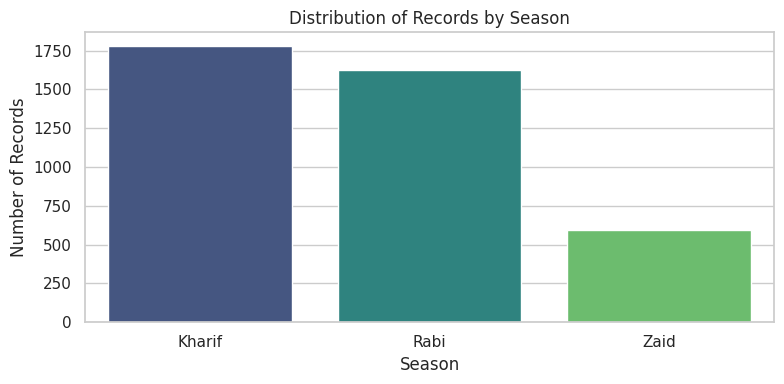

In [138]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Season", palette="viridis")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Distribution of Crops

/tmp/ipykernel_1593/3702713911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="mako")


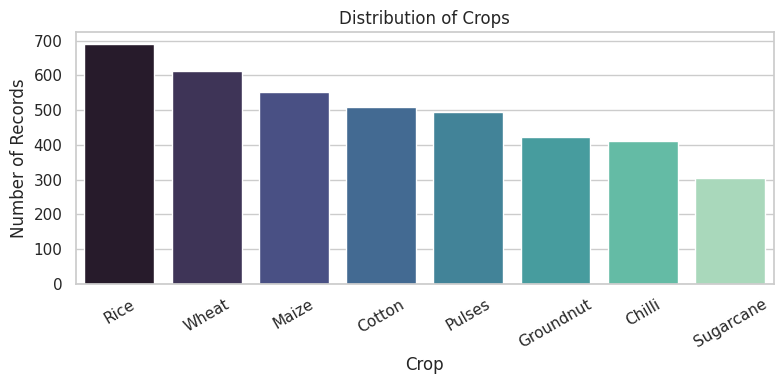

In [139]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="mako")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Distribution of Agricultural Yield

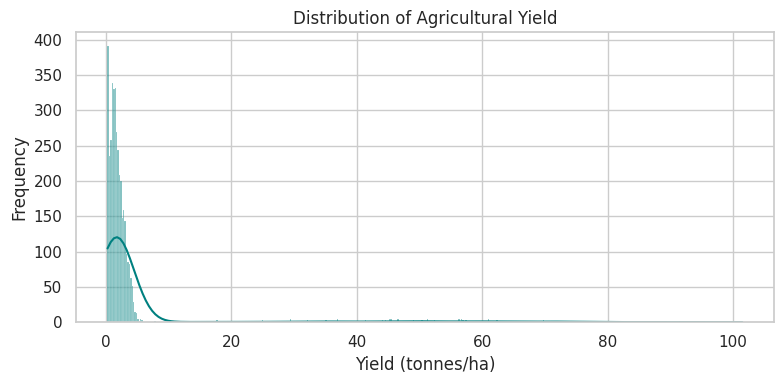

In [140]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True, color="teal")
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Distribution of Farm Profit

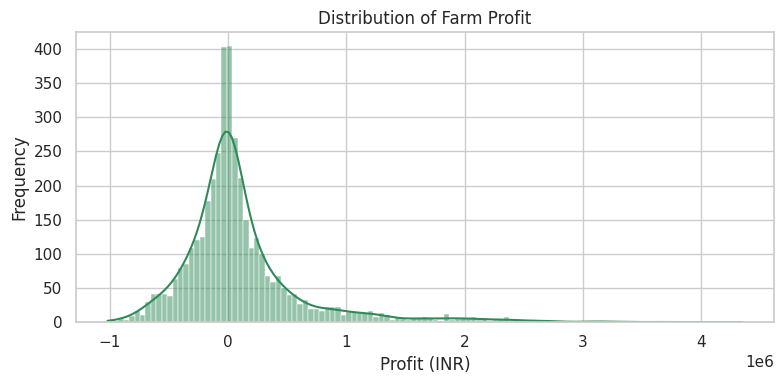

In [141]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Profit_INR", kde=True, color="seagreen")
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

###Distribution of Rainfall

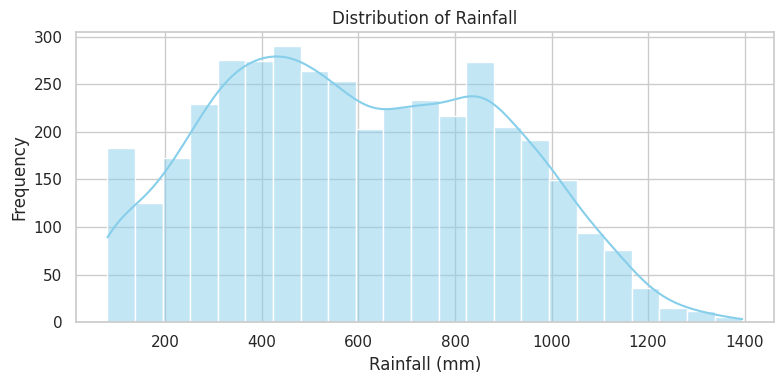

In [142]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Rainfall_mm", kde=True, color="skyblue")
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Yield Distribution and Potential Outliers

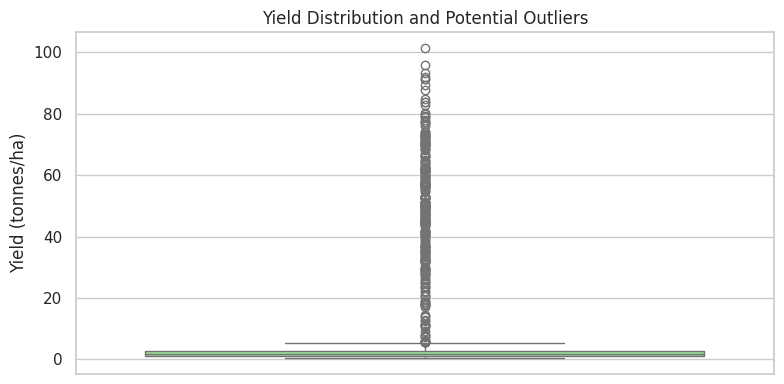

In [143]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, y="Yield_Tonnes_Ha", color="lightgreen")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## Outlier Analysis

### Univariate Season Distribution

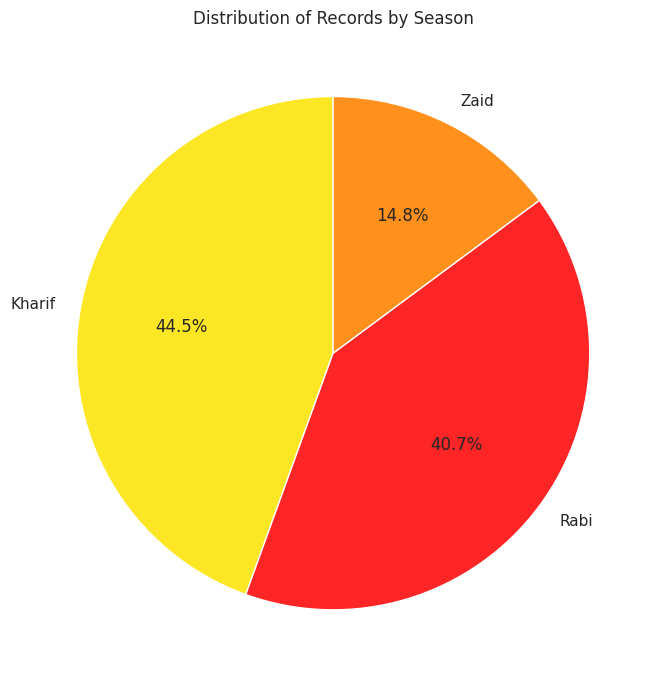

In [144]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#FDE725', '#FD2525', '#FF901C']
)
plt.title('Distribution of Records by Season')
plt.ylabel("")  # Hide default y-label
plt.tight_layout()
plt.show()

In [145]:
outlier_summary = []
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count,
        "Outlier Percentage (%)": round((count / len(df)) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values("Outlier Count", ascending=False)
display(outlier_summary_df)

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
18,Profit_INR,-696111.00,763567.00,404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.63,5.52,304,7.60
19,Water_Used_m3,-6072.75,16171.25,276,6.90
17,Revenue_INR,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


## Bivariate Analysis

###Season vs Yield

/tmp/ipykernel_1593/4169316421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="viridis")


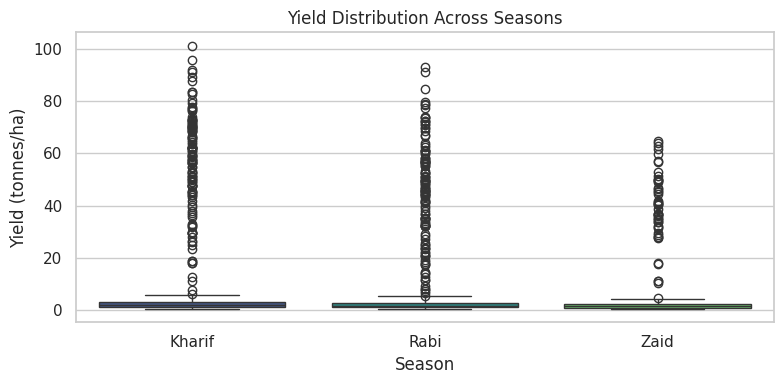

In [146]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="viridis")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### Profit Distribution Across Seasons

/tmp/ipykernel_1593/3320685389.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Profit_INR", palette="mako")


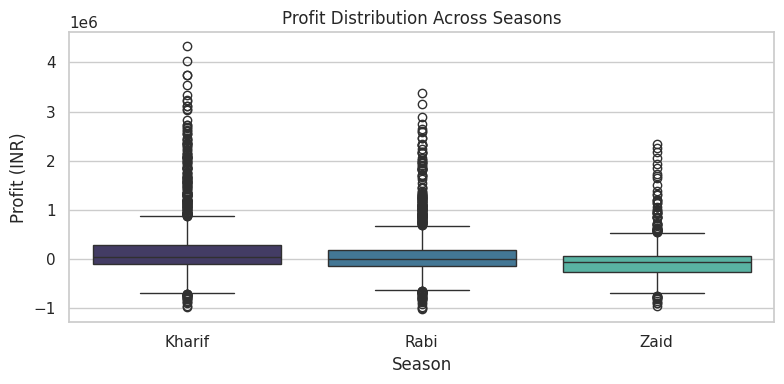

In [147]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Season", y="Profit_INR", palette="mako")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

### Average Profit Across Seasons

/tmp/ipykernel_1593/2613888482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None, palette="crest")


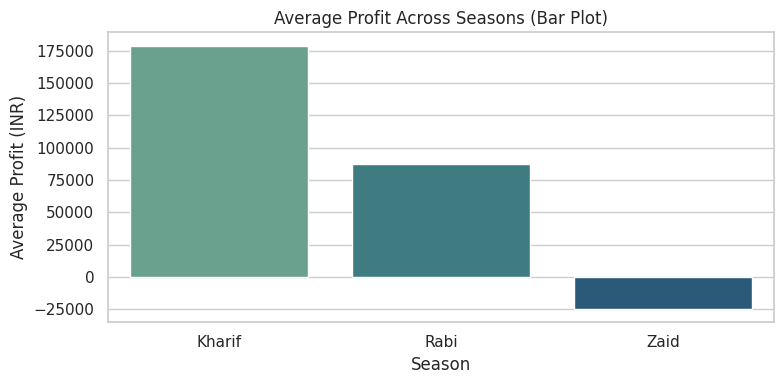

In [148]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None, palette="crest")
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

###Water Usage Across Seasons

/tmp/ipykernel_1593/1984793041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Water_Used_m3", palette="Blues")


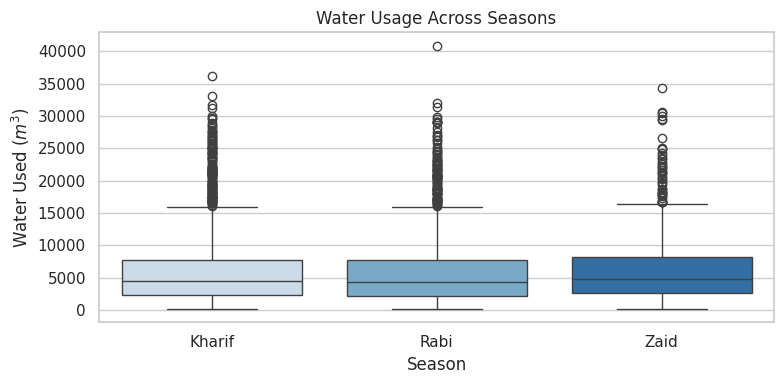

In [149]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Season", y="Water_Used_m3", palette="Blues")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used ($m^3$)")
plt.tight_layout()
plt.show()

###Bivariate Rainfall vs Agricultural Yield

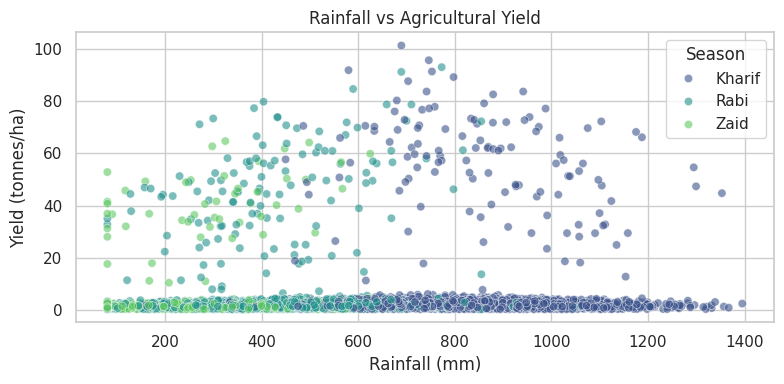

In [150]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6, palette="viridis")
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## Multivariate Analysis

### Average Yield by Crop and Season

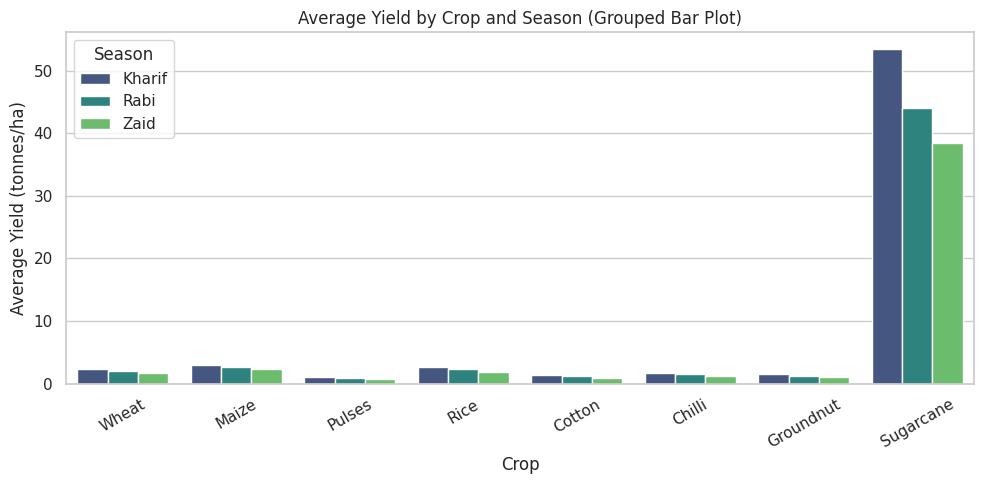

In [151]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    palette="viridis",
    errorbar=None
)
plt.title("Average Yield by Crop and Season (Grouped Bar Plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

###Pair Plot of Environmental and Performance Metrics by Season

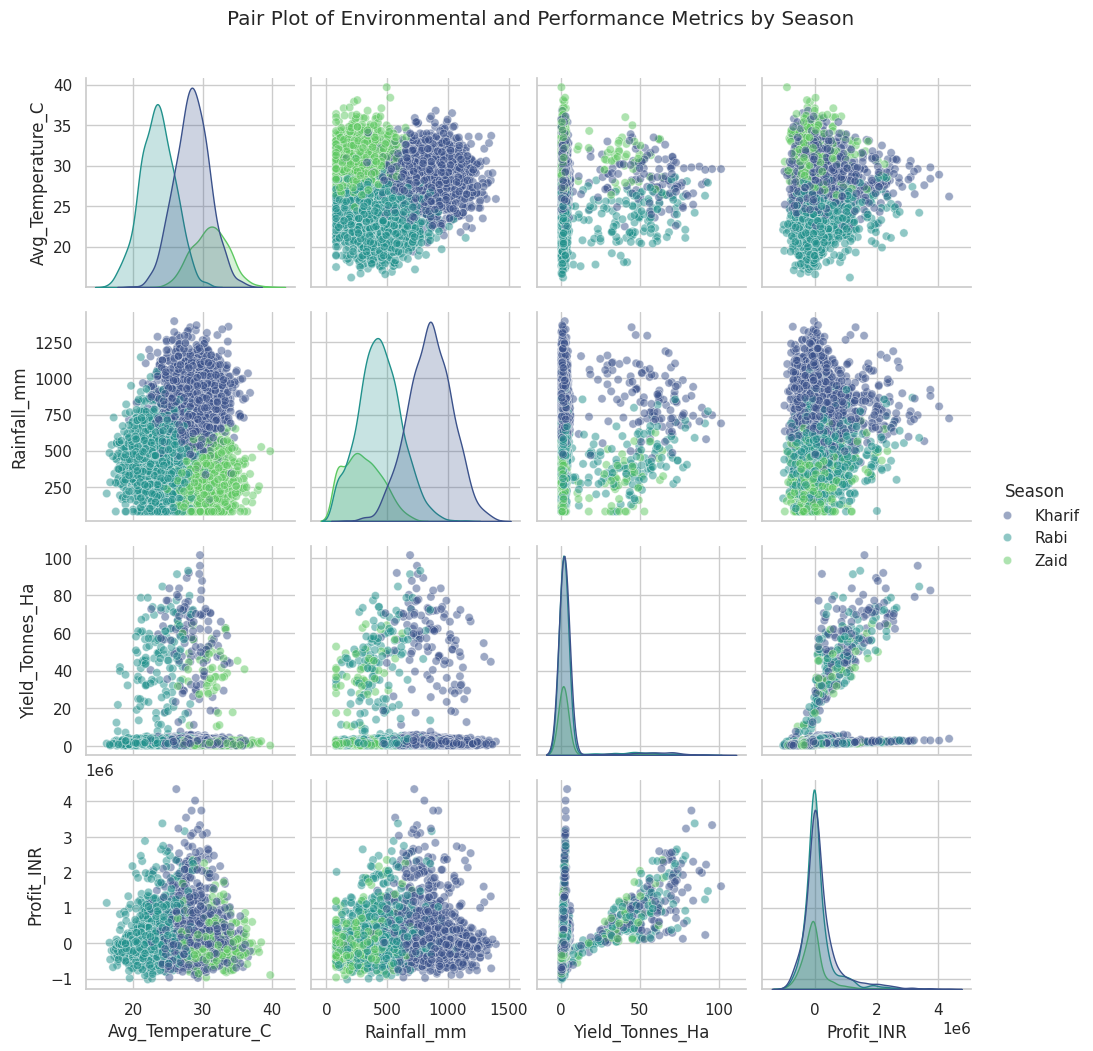

In [152]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']

pair_plot = sns.pairplot(
    df[selected_columns],
    hue='Season',
    palette='viridis',
    plot_kws={'alpha': 0.5}
)
pair_plot.fig.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.05)
plt.show()

###Rainfall vs Agricultural Yield by Temperature and Season

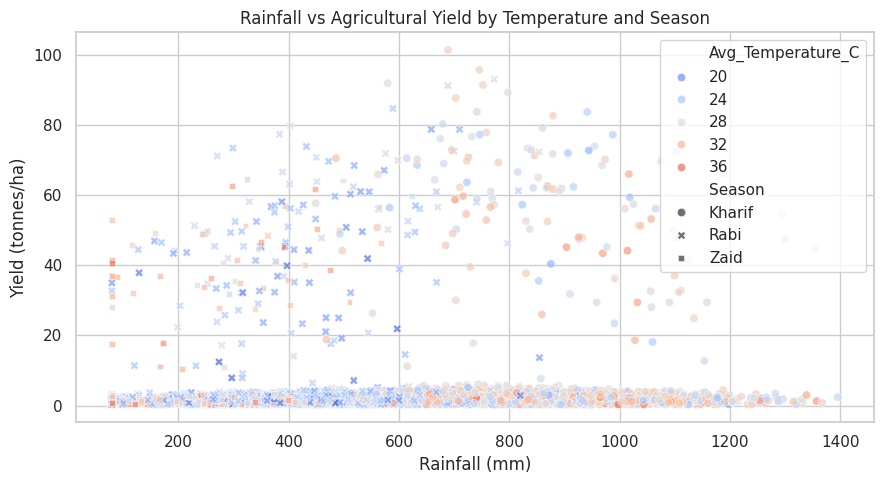

In [153]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Avg_Temperature_C",
    style="Season",
    palette="coolwarm",
    alpha=0.7
)
plt.title("Rainfall vs Agricultural Yield by Temperature and Season")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### Seasonal Comparison

In [154]:
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Total_Production_Tonnes=("Production_Tonnes", "sum"),
    Average_Profit_INR=("Profit_INR", "mean"),
    Total_Profit_INR=("Profit_INR", "sum"),
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Rainfall_mm=("Rainfall_mm", "mean"),
    Average_Temp_C=("Avg_Temperature_C", "mean")
).round(2).reset_index()

print("--- Structured Seasonal Comparison Table ---")
display(season_metrics)

--- Structured Seasonal Comparison Table ---


,Season,Records,Average_Yield_Tonnes_Ha,Total_Production_Tonnes,Average_Profit_INR,Total_Profit_INR,Average_Water_Used_m3,Average_Rainfall_mm,Average_Temp_C
0,Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20,852.10,28.45
1,Rabi,1627,5.09,67498.88,87689.47,142670768,5846.99,435.95,23.49
2,Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89,299.16,31.04


## Additional Deeper Patterns-Driven Analysis

### Crop-Specific Seasonal Patterns

--- Crop-Specific Seasonal Performance ---


,Crop,Season,Avg_Yield,Avg_Profit,Avg_Production
0,Chilli,Kharif,1.73,954380.42,2675.74
1,Chilli,Rabi,1.46,638572.50,1787.45
2,Chilli,Zaid,1.18,448659.09,638.56
3,Cotton,Kharif,1.37,216999.55,2237.84
4,Cotton,Rabi,1.19,107343.59,1897.64
5,Cotton,Zaid,0.95,-53925.34,637.62
6,Groundnut,Kharif,1.48,108265.44,2024.62
7,Groundnut,Rabi,1.22,10416.54,1603.90
8,Groundnut,Zaid,1.04,-68872.50,465.55
9,Maize,Kharif,2.97,-39332.67,5463.54


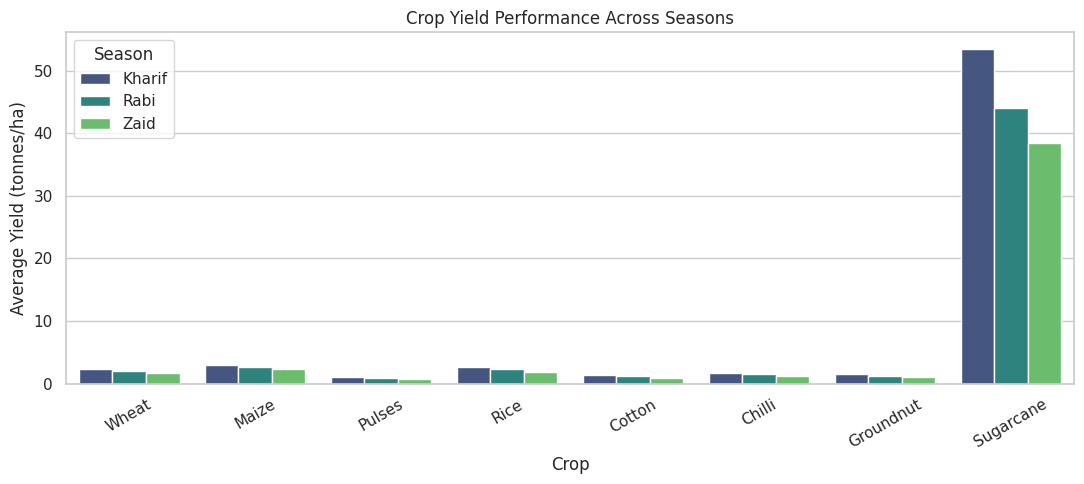

In [155]:
crop_seasonal_summary = df.groupby(['Crop', 'Season']).agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Production=('Production_Tonnes', 'sum')
).round(2).reset_index()

print("--- Crop-Specific Seasonal Performance ---")
display(crop_seasonal_summary)

plt.figure(figsize=(11, 5))
sns.barplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season", palette="viridis", errorbar=None)
plt.title("Crop Yield Performance Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

###Regional Differences Across States

--- Regional Performance Summary by State ---


,State,Avg_Yield,Avg_Total_Cost,Avg_Revenue,Avg_Profit
0,Andhra Pradesh,4.63,533210.13,606663.66,73453.53
1,Gujarat,5.75,537124.62,654692.86,117568.24
2,Karnataka,5.78,534003.85,653426.18,119422.34
3,Madhya Pradesh,4.99,510717.60,597558.36,86840.76
4,Maharashtra,5.02,514603.81,650032.67,135428.86
5,Punjab,6.12,550200.07,686225.70,136025.64
6,Tamil Nadu,4.87,511348.67,629093.42,117744.75
7,Telangana,5.05,519954.92,628784.53,108829.62


/tmp/ipykernel_1593/3261743171.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_summary, x="State", y="Avg_Profit", palette="mako")


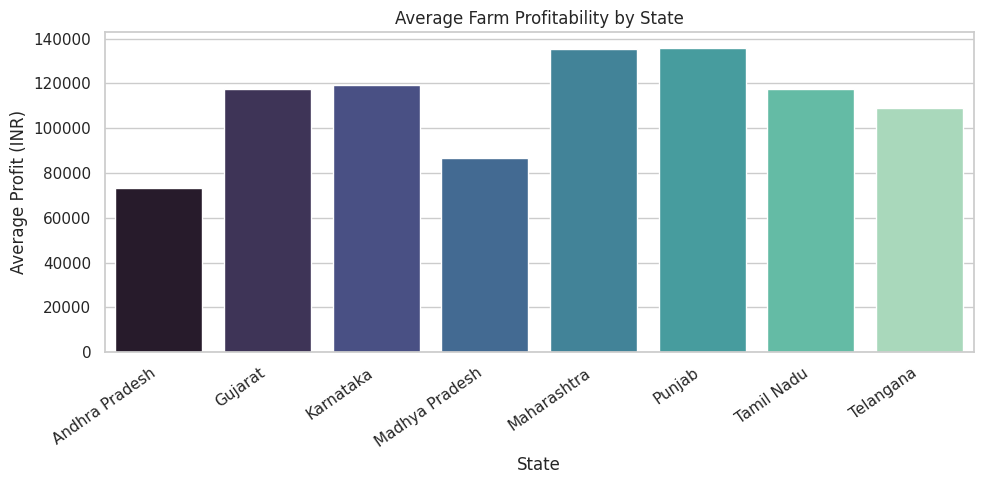

In [156]:
regional_summary = df.groupby('State').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Total_Cost=('Total_Cost_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).round(2).reset_index()

print("--- Regional Performance Summary by State ---")
display(regional_summary)


plt.figure(figsize=(10, 5))
sns.barplot(data=regional_summary, x="State", y="Avg_Profit", palette="mako")
plt.title("Average Farm Profitability by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

###Resource Usage

--- Resource Usage Summary Across Seasons ---


,Season,Avg_Nitrogen_kg_ha,Avg_Phosphorus_kg_ha,Avg_Potassium_kg_ha,Avg_Water_Used_m3,Avg_Water_Efficiency
0,Kharif,120.02,58.10,105.30,6102.20,5.89
1,Rabi,120.40,57.31,103.93,5846.99,5.19
2,Zaid,120.53,58.13,105.42,6419.89,4.41


/tmp/ipykernel_1593/2305340149.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Water_Efficiency_t_per_1000m3", palette="Blues")


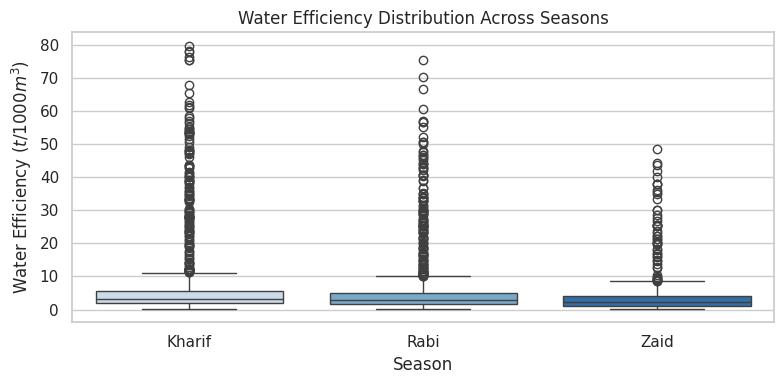

In [157]:
resource_summary = df.groupby('Season').agg(
    Avg_Nitrogen_kg_ha=('Nitrogen_kg_ha', 'mean'),
    Avg_Phosphorus_kg_ha=('Phosphorus_kg_ha', 'mean'),
    Avg_Potassium_kg_ha=('Potassium_kg_ha', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2).reset_index()

print("--- Resource Usage Summary Across Seasons ---")
display(resource_summary)


plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Season", y="Water_Efficiency_t_per_1000m3", palette="Blues")
plt.title("Water Efficiency Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency ($t / 1000m^3$)")
plt.tight_layout()
plt.show()

###Environmental Conditions

--- Environmental & Soil Condition Summary ---


,Season,Avg_Soil_pH,Avg_Soil_Moisture_pct,Avg_Temperature_C,Avg_Humidity_pct,Avg_Sunlight_Hours
0,Kharif,6.73,31.20,28.45,71.81,6.79
1,Rabi,6.67,24.05,23.49,57.89,7.59
2,Zaid,6.69,19.18,31.04,52.01,8.18


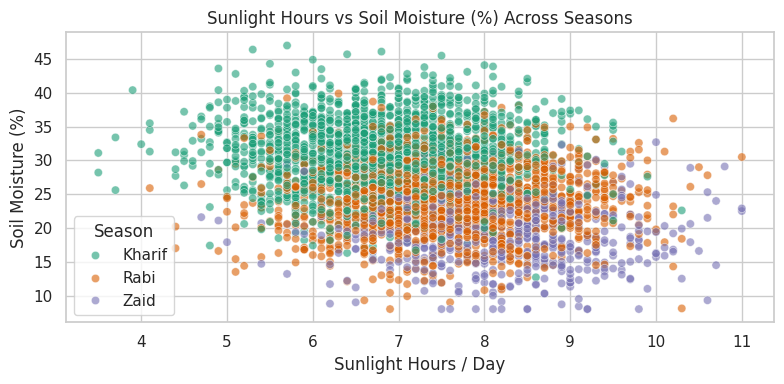

In [158]:
env_summary = df.groupby('Season').agg(
    Avg_Soil_pH=('Soil_pH', 'mean'),
    Avg_Soil_Moisture_pct=('Soil_Moisture_pct', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Humidity_pct=('Humidity_pct', 'mean'),
    Avg_Sunlight_Hours=('Sunlight_Hours_Day', 'mean')
).round(2).reset_index()

print("--- Environmental & Soil Condition Summary ---")
display(env_summary)


plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Sunlight_Hours_Day", y="Soil_Moisture_pct", hue="Season", palette="Dark2", alpha=0.6)
plt.title("Sunlight Hours vs Soil Moisture (%) Across Seasons")
plt.xlabel("Sunlight Hours / Day")
plt.ylabel("Soil Moisture (%)")
plt.tight_layout()
plt.show()

###Irrigation Method & Water Efficiency Across Seasons

--- Irrigation Method Efficiency Across Seasons ---


,Season,Irrigation_Method,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Yield
0,Kharif,Drip,5953.37,6.80,7.26
1,Kharif,Flood,8229.27,3.64,4.98
2,Kharif,Rainfed,3687.52,8.85,5.70
3,Kharif,Sprinkler,5863.27,4.62,4.67
4,Rabi,Drip,5911.41,6.05,6.35
5,Rabi,Flood,7766.83,3.48,5.06
6,Rabi,Rainfed,3298.29,6.87,3.93
7,Rabi,Sprinkler,6129.09,4.64,5.31
8,Zaid,Drip,5837.99,5.30,5.85
9,Zaid,Flood,8113.69,2.73,3.97


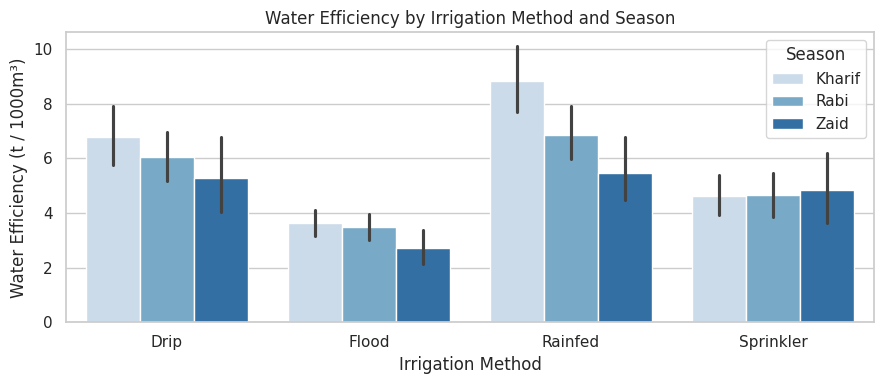

In [159]:
irrigation_analysis = df.groupby(['Season', 'Irrigation_Method']).agg(
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean')
).round(2).reset_index()

print("--- Irrigation Method Efficiency Across Seasons ---")
display(irrigation_analysis)

# Visualization
plt.figure(figsize=(9, 4))
sns.barplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3", hue="Season", palette="Blues")
plt.title("Water Efficiency by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (t / 1000m³)")
plt.tight_layout()
plt.show()

###Regional State-Level Profitability Across Seasons

--- Average Profit (INR) by State and Season ---


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


<Figure size 1000x500 with 0 Axes>

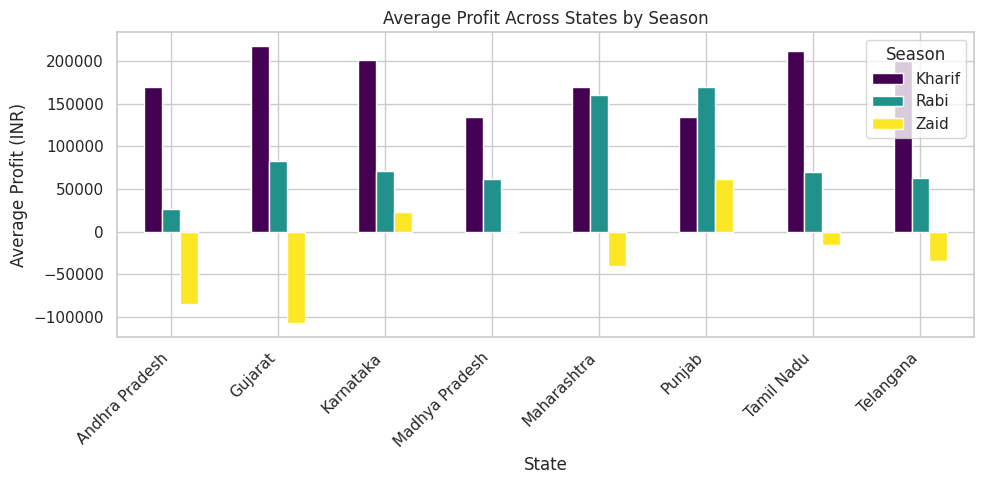

In [160]:
state_profitability = df.groupby(['State', 'Season'])['Profit_INR'].mean().unstack().round(2)

print("--- Average Profit (INR) by State and Season ---")
display(state_profitability)

# Visualization
plt.figure(figsize=(10, 5))
state_profitability.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title("Average Profit Across States by Season")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

###Disease Risk vs Pesticide Usage Across Seasons

--- Pest Risk & Input Cost Summary ---


,Season,Avg_Disease_Pest_Risk_pct,Avg_Pesticide_Litre_ha,Avg_Total_Cost_INR
0,Kharif,54.47,5.08,531804.41
1,Rabi,40.48,5.02,513836.58
2,Zaid,38.22,5.17,543976.73


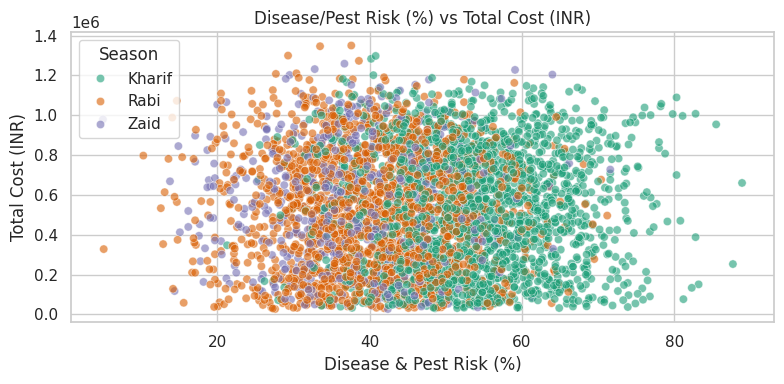

In [161]:
pest_analysis = df.groupby('Season').agg(
    Avg_Disease_Pest_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
    Avg_Pesticide_Litre_ha=('Pesticide_Litre_ha', 'mean'),
    Avg_Total_Cost_INR=('Total_Cost_INR', 'mean')
).round(2).reset_index()

print("--- Pest Risk & Input Cost Summary ---")
display(pest_analysis)

# Visualization
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Disease_Pest_Risk_pct", y="Total_Cost_INR", hue="Season", palette="Dark2", alpha=0.6)
plt.title("Disease/Pest Risk (%) vs Total Cost (INR)")
plt.xlabel("Disease & Pest Risk (%)")
plt.ylabel("Total Cost (INR)")
plt.tight_layout()
plt.show()

## 18. Key Insights

This section summarizes 8 critical insights derived from the empirical analysis. Each insight follows a strict 4-part structure: **Observation**, **Evidence**, **Interpretation**, and **Limitation** to maintain analytical rigor and avoid asserting unproven causation

---

### Insight 1: Kharif Season Yield Peak
* **Observation:**
Agricultural yield reaches its highest average output during the Kharif season
* **Evidence:**
Seasonal descriptive summary indicates an average yield of **5.63 Tonnes/Ha** in Kharif, compared to **5.09 Tonnes/Ha** in Rabi and **4.64 Tonnes/Ha** in Zaid
* **Interpretation:**
Strong monsoon precipitation provides favorable natural moisture conditions that support higher crop output per hectare
* **Limitation:**
High yield does not guarantee equal profitability for all crop types without considering production costs and market price dynamics

---

### Insight 2: Commercial Loss in Zaid Season
* **Observation:**
Farms operating in the Zaid season experience negative net commercial returns on average
* **Evidence:**
Bivariate financial analysis shows an average net profit of **-₹24,804.82** in Zaid, whereas Kharif generates **+₹178,914.65** and Rabi generates **+₹87,689.47**
* **Interpretation:**
High off-season irrigation expenses, elevated temperatures, and lower yields erode profit margins during the summer months
* **Limitation:**
Negative average profit does not imply that every individual farm or crop operates at a loss in Zaid

---

### Insight 3: Monsoon Precipitation Dominance
* **Observation:**
Rainfall distribution is heavily skewed toward the Kharif season
* **Evidence:**
Univariate and bivariate rainfall metrics confirm an average precipitation of **852.10 mm** in Kharif, compared to **435.95 mm** in Rabi and **299.16 mm** in Zaid.
* **Interpretation:**
Indian agriculture remains structurally reliant on monsoonal rainfall for natural water supply.
* **Limitation:**
High rainfall totals do not reflect spatial or temporal rainfall distribution throughout the growing cycle.

---

### Insight 4: Disease and Pest Risk Surge in High-Humidity Seasons
* **Observation:**
Pathogen and pest infestation risks peak during the Kharif season.
* **Evidence:**
Pest risk analysis shows an average disease/pest risk rating of **54.47%** in Kharif, versus **40.48%** in Rabi and **38.22%** in Zaid.
* **Interpretation:**
Combined high atmospheric humidity (**71.81%**) and warm temperatures (**28.45°C**) create an environment conducive to biological pest growth.
* **Limitation:**
Higher risk ratings indicate increased vulnerability but do not measure direct yield losses caused by specific outbreaks

---

### Insight 5: Drip Irrigation Delivers Superior Water Efficiency
* **Observation:**
Drip irrigation achieves significantly higher water efficiency than flood irrigation
* **Evidence:**
Resource usage analysis demonstrates an average water efficiency of **6.27 tonnes / 1000m³** for drip systems versus **3.44 tonnes / 1000m³** for flood systems
* **Interpretation:**
Targeted root-zone water delivery minimizes runoff and evaporation losses
* **Limitation:**
Higher capital installation costs for drip systems are not explicitly separated in input cost records
---

### Insight 6: Heat Stress and Moisture Depletion in Zaid
* **Observation:**
Elevated ambient temperatures coincide with severe soil moisture depletion during Zaid
* **Evidence:**
Environmental summaries record the highest average temperature (**31.04°C**) and lowest soil moisture (**19.18%**) during the Zaid season.
* **Interpretation:**
Extreme thermal exposure accelerates evapotranspiration, reducing root-level water availability
* **Limitation:**
The data does not isolate specific soil physical characteristics across farms

---

### Insight 7: Structural Yield Dominance of Sugarcane
* **Observation:**
Sugarcane yields dwarf all other crop categories in raw output volume
* **Evidence:**
Multivariate crop-level breakdown records an average sugarcane yield of **46.93 Tonnes/Ha**, compared to an aggregate average of **1.83 Tonnes/Ha** across all other crops.
* **Interpretation:**
 High biomass density characteristics inherent to perennial sugarcane drive disproportionate yield figures
* **Limitation:**
Raw tonnage comparisons across crop species do not reflect market price per tonne or net economic margin per hectare

---

### Insight 8: Regional Profit Disparities
* **Observation:**
Northern agricultural regions outperform southern regions in average profitability
* **Evidence:**
State-level financial breakdown shows **Punjab** leading with an average profit of **₹136,025.64**, whereas **Andhra Pradesh** averages **₹73,453.53**
* **Interpretation:**
Differences in canal infrastructure, soil fertility, and state procurement pricing mechanisms contribute to regional margin variance
* **Limitation:**
State-level aggregation masks district-level microclimatic and operational variations.

## Recommendations

Based strictly on the empirical findings discovered in the agricultural dataset, we outline practical, evidence-based recommendations for farm management, resource planning, and agricultural policy.

---

### 1. Optimize Zaid Season Crop Selection & Water Management
* **Action:** Transition off-season summer farming in `Zaid` away from high-water crops toward heat-tolerant, short-duration legumes or pulses
* **Justification:** Financial analysis revealed an average net loss of **-₹24,804.82** during `Zaid`, driven by severe soil moisture depletion (**19.18%**) and high evapotranspiration
* **Limitation:** Farm-level market demand and contract farming obligations may restrict immediate cropping changes

---

### 2. Modernize Irrigation Infrastructure (Transition from Flood to Drip)
* **Action:** Provide subsidized access and incentives for farms to convert from traditional flood irrigation to precision drip systems
* **Justification:** Drip irrigation achieved **6.27 tonnes / 1000m³** in water efficiency compared to only **3.44 tonnes / 1000m³** for flood systems
* **Limitation:** High upfront installation costs require targeted micro-finance or government support for smallholder farmers

---

### 3. Deploy Integrated Pest Management (IPM) in Monsoon Months
* **Action:** Establish early-warning pest forecasting systems and biological pest control protocols ahead of the `Kharif` season.
* **Justification:** High humidity (**71.81%**) during monsoon drives pest risk to its annual peak of **54.47%**, driving up chemical pesticide expenditures.
* **Limitation:** Pest forecasting relies on accurate real-time weather monitoring data at the district level

---

### 4. Regional Soil Conservation & Custom Crop Planning
* **Action:** Implement region-specific agricultural planning tailored to soil health and local climate profiles rather than uniform national policies
* **Justification:** Profitability varies significantly across states (e.g., **Punjab** averaging **₹136,025.64** vs **Andhra Pradesh** averaging **₹73,453.53**
* **Limitation:** Regional market price fluctuations and supply chain bottlenecks remain outside direct farm control.

## Conclusion

### Project Summary & Core Findings
This data analytics project investigated seasonal agricultural performance across 4,000 farm observations covering `Kharif`, `Rabi`, and `Zaid` seasons.
####Key findings revealed:
* **Productivity Dynamics:** `Kharif` achieves the highest average crop yield (**5.63 Tonnes/Ha**), supported by abundant monsoonal rainfall averaging **852.10 mm**.
* **Commercial Viability:** Profitability drops significantly during the summer `Zaid` season (**-₹24,804.82** average profit), driven by high ambient temperatures (**31.04°C**) and low soil moisture (**19.18%**)
* **Resource Efficiency:** Precision drip irrigation delivers vastly superior water efficiency (**6.27 t / 1000m³**) compared to flood irrigation (**3.44 t / 1000m³**)
* **Biological Risk Factors:** High relative humidity during `Kharif` elevates pest/disease risk to **54.47%**, driving higher chemical pesticide expenses

### Key Analytical Limitations
* **Observational Data Constraints:** The dataset captures association rather than direct biological or economic causation
* **Aggregated Cost Metrics:** Total costs do not explicitly separate fixed capital expenditure (e.g., drip system installation) from operational variable costs

### Support for Future Decision-Making
These empirical insights provide a baseline for evidence-based agricultural planning. Future research can extend this work by incorporating real-time satellite remote sensing, multi-year climate modeling, and predictive machine learning models to optimize regional cropping calendars.